In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ydata_profiling as yp
import warnings
warnings.filterwarnings('ignore')

In [4]:
pd.set_option('display.float_format',lambda x: '%.3f' %x)
pd.set_option ('display.max_columns',None)
pd.set_option('display.max_rows',100)
print ("MAX ROWS- ",pd.get_option('display.max_rows'))
print ("MAX COLUMNS-",pd.get_option('display.max_columns'))
print ("FLOAT FORMAT-", pd.get_option('display.float_format'))

MAX ROWS-  100
MAX COLUMNS- None
FLOAT FORMAT- <function <lambda> at 0x0000018FC7AE0720>


In [7]:
ipl_auction_df=pd.read_csv('IPL IMB381IPL2013.csv')
ipl_auction_df

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.000,0,0.000,0,0,0,0.000,0.000,0,307,15,20.470,8.900,13.930,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.410,185,37.600,0,0,0,0.000,0.000,0,29,0,0.000,14.500,0.000,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.620,288,32.900,0,167,39,18.560,121.010,5,1059,29,36.520,8.810,24.900,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.560,51,36.800,0,58,11,5.800,76.320,0,1125,49,22.960,6.230,22.140,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.930,0,0.000,0,1317,71,32.930,120.710,28,0,0,0.000,0.000,0.000,2011,100000,800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,126,"Yadav, AS",2,IND,DC,Batsman,0,0,0,0.000,0,0.000,0,49,16,9.800,125.640,2,0,0,0.000,0.000,0.000,2010,50000,750000
126,127,Younis Khan,2,PAK,RR,Batsman,6398,7,6814,75.780,3,86.600,1,3,3,3.000,42.850,0,0,0,0.000,0.000,0.000,2008,225000,225000
127,128,Yuvraj Singh,2,IND,KXIP+,Batsman,1775,9,8051,87.580,109,44.300,1,1237,66,26.320,131.880,67,569,23,24.740,7.020,21.130,2011,400000,1800000
128,129,Zaheer Khan,2,IND,MI+,Bowler,1114,288,790,73.550,278,35.400,0,99,23,9.900,91.670,1,1783,65,27.430,7.750,21.260,2008,200000,450000


In [12]:
list_col=[]
list_col=list(ipl_auction_df.columns)
list_col

['Sl.NO.',
 'PLAYER NAME',
 'AGE',
 'COUNTRY',
 'TEAM',
 'PLAYING ROLE',
 'T-RUNS',
 'T-WKTS',
 'ODI-RUNS-S',
 'ODI-SR-B',
 'ODI-WKTS',
 'ODI-SR-BL',
 'CAPTAINCY EXP',
 'RUNS-S',
 'HS',
 'AVE',
 'SR-B',
 'SIXERS',
 'RUNS-C',
 'WKTS',
 'AVE-BL',
 'ECON',
 'SR-BL',
 'AUCTION YEAR',
 'BASE PRICE',
 'SOLD PRICE']

In [15]:
dataframe_shape=ipl_auction_df.shape
#type(dataframe_shape)
dataframe_shape

(130, 26)

In [16]:
dataframe_info=ipl_auction_df.info()
dataframe_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    object 
 4   TEAM           130 non-null    object 
 5   PLAYING ROLE   130 non-null    object 
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C    

In [35]:
dataframe_transpose=ipl_auction_df.transpose(copy=False)
dataframe_transpose

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129
Sl.NO.,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130
PLAYER NAME,"Abdulla, YA",Abdur Razzak,"Agarkar, AB","Ashwin, R","Badrinath, S","Bailey, GJ","Balaji, L","Bollinger, DE","Botha, J","Boucher, MV","Bravo, DJ","Chanderpaul, S","Chawla, PP","de Villiers, AB","Dhawan, S","Dhoni, MS","Dilshan, TM","Dinda, AB","Dravid, RS","Duminy, J-P","Edwards, FH","Fernando, CRD","Fleming, SP","Flintoff, A","Gambhir, G","Ganguly, SC","Gayle, CH","Gibbs, HH","Gilchrist, AC","Gony, MS",Harbhajan Singh,"Harris, RJ","Hayden, ML","Henderson, T","Henriques, MC","Hodge, BJ","Hopes, JR","Hussey, DJ","Hussey, MEK","Jadeja, RA","Jaffer, W","Jayasuriya, ST","Jayawardena, DPMD","Kaif, M","Kallis, JH",Kamran Akmal,Kamran Khan,"Karthik, KD","Kartik, M","Katich, SM","Kohli, V","Kumar, P","Kumble, A","Langeveldt, CK","Laxman, VVS","Lee, B","Maharoof, MF","Malinga, SL","Mascarenhas, AD","Mathews, AD","McCullum, BB","McDonald, AB","McGrath, GD",Misbah-ul-Haq,"Mishra, A","Mithun, A",Mohammad Asif,"Morkel, JA","Morkel, M","Muralitharan, M","Nannes, DP","Nayar, AM","Nehra, A","Noffke, AA","Ntini, M","Ojha, NV","Ojha, PP","Oram, JDP",Pankaj Singh,"Patel, MM","Patel, PA","Pathan, IK","Pathan, YK","Pietersen, KP","Pollock, SM","Pomersbach, LA","Ponting, RT","Powar, RR","Raina, SK","Ryder, JD","Saha, WP","Sangakkara, KC","Sarwan, RR","Sehwag, V",Shahid Afridi,"Sharma, I","Sharma, J","Sharma, RG",Shoaib Akhtar,Shoaib Malik,"Silva, LPC","Singh, RP","Smith, DR","Smith, GC",Sohail Tanvir,"Sreesanth, S","Steyn, DW","Styris, SB","Symonds, A","Taibu, T","Taylor, LRPL","Tendulkar, SR","Tiwary, MK","Tiwary, SS","Tyagi, S",Umar Gul,"Uthappa, RV","Vaas, WPUJC",Van der Merwe,"Venugopal Rao, Y","Vettori, DL","Vinay Kumar, R","Warne, SK","Warner, DA","White, CL","Yadav, AS",Younis Khan,Yuvraj Singh,Zaheer Khan,"Zoysa, DNT"
AGE,2,2,2,1,2,2,2,2,2,2,2,3,1,2,2,2,2,2,3,2,2,2,3,2,2,3,2,3,3,2,2,2,3,3,1,3,2,2,3,1,2,3,2,2,3,2,1,2,2,3,1,1,3,3,3,2,2,2,2,1,2,2,3,3,2,1,2,2,2,3,3,2,2,2,2,2,1,2,2,2,2,2,2,2,3,2,3,2,1,2,2,2,2,2,2,1,2,1,3,2,2,2,2,2,2,2,2,3,3,2,2,3,2,1,1,2,2,3,2,2,2,2,3,1,2,2,2,2,2,2
COUNTRY,SA,BAN,IND,IND,IND,AUS,IND,AUS,SA,SA,WI,WI,IND,SA,IND,IND,SL,IND,IND,SA,WI,SL,NZ,ENG,IND,IND,WI,SA,AUS,IND,IND,AUS,AUS,SA,AUS,AUS,AUS,AUS,AUS,IND,IND,SL,SL,IND,SA,PAK,IND,IND,IND,AUS,IND,IND,IND,SA,IND,AUS,SL,SL,ENG,SL,NZ,AUS,AUS,PAK,IND,IND,PAK,SA,SA,SL,AUS,IND,IND,AUS,SA,IND,IND,NZ,IND,IND,IND,IND,IND,ENG,SA,AUS,AUS,IND,IND,NZ,IND,SL,WI,IND,PAK,IND,IND,IND,PAK,PAK,SL,IND,WI,SA,PAK,IND,SA,NZ,AUS,ZIM,NZ,IND,IND,IND,IND,PAK,IND,SL,SA,IND,NZ,IND,AUS,AUS,AUS,IND,PAK,IND,IND,SL
TEAM,KXIP,RCB,KKR,CSK,CSK,CSK,CSK+,CSK,RR,RCB+,MI+,RCB,KXIP,DD+,MI+,CSK,DD+,KKR+,RCB+,MI+,DC,MI,CSK,CSK,DD+,KKR+,KKR+,DC,DC+,CSK+,MI,DC+,CSK,RR,KKR+,KKR+,KXIP,KKR+,CSK,RR+,RCB,MI,KXIP+,RR+,RCB,RR,RR+,DD+,KKR+,KXIP,RCB,RCB+,RCB,KKR+,DC+,KXI+,DD,MI,RR+,KKR+,KKR+,DD+,DD,RCB,DD+,RCB,DD,CSK,RR+,CSK+,DD+,MI+,DD+,RCB,CSK,RR+,DC+,CSK+,RCB+,RR+,CSK+,KXIP+,RR+,RCB+,MI,KXIP+,KKR,KXIP+,CSK,RCB+,KKR+,KXIP+,KXIP,DD,DC,KKR+,CSK,DC+,KKR,DD,DC,DC+,DC+,RR+,RR,KXIP+,RCB+,DC+,DC+,KKR,RCB+,MI,DD+,MI+,CSK,KKR,RCB+,DC,RCB+,DC+,DD+,RCB+,RR,DD,RCB+,DC,RR,KXIP+,MI+,DC
PLAYING ROLE,Allrounder,Bowler,Bowler,Bowler,Batsman,Batsman,Bowler,Bowler,Allrounder,W. Keeper,Allrounder,Batsman,Allrounde

In [19]:
df = pd.DataFrame({'Weight':[45, 88, 56, 15, 71],
                   'Name':['Sam', 'Andrea', 'Alex', 'Robin', 'Kia'],
                   'Age':[14, 25, 55, 8, 21]})
df

,Weight,Name,Age
0,45,Sam,14
1,88,Andrea,25
2,56,Alex,55
3,15,Robin,8
4,71,Kia,21


In [22]:
index_=pd.date_range('2024-09-17 16:02',periods=5, freq='H')
df.index=index_
print (df)

                     Weight    Name  Age
2024-09-17 16:02:00      45     Sam   14
2024-09-17 17:02:00      88  Andrea   25
2024-09-17 18:02:00      56    Alex   55
2024-09-17 19:02:00      15   Robin    8
2024-09-17 20:02:00      71     Kia   21


In [23]:
result=df.transpose()
result

,2024-09-17 16:02:00,2024-09-17 17:02:00,2024-09-17 18:02:00,2024-09-17 19:02:00,2024-09-17 20:02:00
Weight,45,88,56,15,71
Name,Sam,Andrea,Alex,Robin,Kia
Age,14,25,55,8,21


In [26]:
#Slicing and indexing a DataFrame.
df_top5=ipl_auction_df[0:5]
df_top5

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.000,0,0.000,0,0,0,0.000,0.000,0,307,15,20.470,8.900,13.930,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.410,185,37.600,0,0,0,0.000,0.000,0,29,0,0.000,14.500,0.000,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.620,288,32.900,0,167,39,18.560,121.010,5,1059,29,36.520,8.810,24.900,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.560,51,36.800,0,58,11,5.800,76.320,0,1125,49,22.960,6.230,22.140,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.930,0,0.000,0,1317,71,32.930,120.710,28,0,0,0.000,0.000,0.000,2011,100000,800000


In [29]:
df_last5=ipl_auction_df[-5:]
df_last5

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
125,126,"Yadav, AS",2,IND,DC,Batsman,0,0,0,0.000,0,0.000,0,49,16,9.800,125.640,2,0,0,0.000,0.000,0.000,2010,50000,750000
126,127,Younis Khan,2,PAK,RR,Batsman,6398,7,6814,75.780,3,86.600,1,3,3,3.000,42.850,0,0,0,0.000,0.000,0.000,2008,225000,225000
127,128,Yuvraj Singh,2,IND,KXIP+,Batsman,1775,9,8051,87.580,109,44.300,1,1237,66,26.320,131.880,67,569,23,24.740,7.020,21.130,2011,400000,1800000
128,129,Zaheer Khan,2,IND,MI+,Bowler,1114,288,790,73.550,278,35.400,0,99,23,9.900,91.670,1,1783,65,27.430,7.750,21.260,2008,200000,450000
129,130,"Zoysa, DNT",2,SL,DC,Bowler,288,64,343,95.810,108,39.400,0,11,10,11.000,122.220,0,99,2,49.500,9.000,33.000,2008,100000,110000


In [30]:
df_slc_by_col_names=ipl_auction_df[['PLAYER NAME','COUNTRY']][0:5]
df_slc_by_col_names

,PLAYER NAME,COUNTRY
0,"Abdulla, YA",SA
1,Abdur Razzak,BAN
2,"Agarkar, AB",IND
3,"Ashwin, R",IND
4,"Badrinath, S",IND


In [40]:
#Select rows and columns by indexes.
iloc_df=ipl_auction_df.iloc[0,1]
iloc_df


'Abdulla, YA'

In [41]:
# The loc and iloc functions in Pandas are used to slice a data set. 
# The function .loc is primarily used for label indexing, while .iloc is mainly used for integer indexing.
iloc_df=ipl_auction_df.iloc[0:4,2:5]
iloc_df

,AGE,COUNTRY,TEAM
0,2,SA,KXIP
1,2,BAN,RCB
2,2,IND,KKR
3,1,IND,CSK


In [49]:
loc_df=ipl_auction_df.loc[ipl_auction_df['COUNTRY']=='IND']
loc_df
#print ("DataFrame Length- ", len(loc_df))

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.620,288,32.900,0,167,39,18.560,121.010,5,1059,29,36.520,8.810,24.900,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.560,51,36.800,0,58,11,5.800,76.320,0,1125,49,22.960,6.230,22.140,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.930,0,0.000,0,1317,71,32.930,120.710,28,0,0,0.000,0.000,0.000,2011,100000,800000
6,7,"Balaji, L",2,IND,CSK+,Bowler,51,27,120,78.940,34,42.500,0,26,15,4.330,72.220,1,1342,52,25.810,7.980,19.400,2011,100000,500000
12,13,"Chawla, PP",1,IND,KXIP,Allrounder,5,3,38,65.510,32,41.000,0,337,24,13.480,113.090,9,1819,73,126.300,38.110,100.200,2008,125000,400000
14,15,"Dhawan, S",2,IND,MI+,Batsman,0,0,69,56.090,0,0.000,0,1540,95,31.430,122.320,36,66,4,16.500,8.250,12.000,2011,100000,300000
15,16,"Dhoni, MS",2,IND,CSK,W. Keeper,3509,0,6773,88.190,1,12.000,1,1782,70,37.130,136.450,64,0,0,0.000,0.000,0.000,2008,400000,1500000
17,18,"Dinda, AB",2,IND,KKR+,Bowler,0,0,18,60.000,5,61.400,0,6,2,1.000,33.330,0,926,36,25.720,7.290,21.190,2011,100000,375000
18,19,"Dravid, RS",3,IND,RCB+,Batsman,13288,1,10889,71.240,4,46.500,1,1703,75,27.920,116.880,23,0,0,0.000,0.000,0.000,2011,400000,500000
24,25,"Gambhir, G",2,IND,DD+,Batsman,3712,0,4819,86.170,0,0.000,1,2065,93,33.310,128.900,32,0,0,0.000,0.000,0.000,2008,220000,725000


In [55]:
#Finding Unique occurrences of values in columns.
unique_occ_df=ipl_auction_df.COUNTRY.value_counts()
unique_occ_df

COUNTRY
IND    53
AUS    22
SA     16
SL     12
PAK     9
NZ      7
WI      6
ENG     3
BAN     1
ZIM     1
Name: count, dtype: int64

In [57]:
#Normalize is used to show rates rather than raw numbers. Eg: instead of showing unemployment in Kansas city as 38000 people you get a rate of 3.3% which
#can be compared to St. Louis 52000 people at 3.6%
unique_occ_df=ipl_auction_df.COUNTRY.value_counts(normalize=True)*100
unique_occ_df

COUNTRY
IND   40.769
AUS   16.923
SA    12.308
SL     9.231
PAK    6.923
NZ     5.385
WI     4.615
ENG    2.308
BAN    0.769
ZIM    0.769
Name: proportion, dtype: float64

In [9]:
#Crosstab
crosstab_df=pd.crosstab(ipl_auction_df['AGE'],ipl_auction_df['PLAYING ROLE'])
crosstab_df

PLAYING ROLE,Allrounder,Batsman,Bowler,W. Keeper
AGE,,,,
1,4,5,7,0
2,25,21,29,11
3,6,13,8,1


In [10]:
df = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male'],
    'Handedness': ['Right-handed', 'Left-handed', 'Right-handed', 'Right-handed', 'Left-handed']
})

ctab = pd.crosstab(df['Gender'], df['Handedness'])
print(ctab)

Handedness  Left-handed  Right-handed
Gender                               
Female                1             1
Male                  1             2


In [13]:
#DATAFRAME SORT
sorted_df=ipl_auction_df[['PLAYER NAME','SOLD PRICE']].sort_values('SOLD PRICE')[0:10]
sorted_df

,PLAYER NAME,SOLD PRICE
73,"Noffke, AA",20000
46,Kamran Khan,24000
0,"Abdulla, YA",50000
1,Abdur Razzak,50000
118,Van der Merwe,50000
5,"Bailey, GJ",50000
85,"Pomersbach, LA",50000
34,"Henriques, MC",50000
61,"McDonald, AB",80000
78,Pankaj Singh,95000


In [14]:
sorted_df_desc=ipl_auction_df[['PLAYER NAME','SOLD PRICE']].sort_values('SOLD PRICE',ascending=False)[0:10]
sorted_df_desc

,PLAYER NAME,SOLD PRICE
93,"Sehwag, V",1800000
127,Yuvraj Singh,1800000
50,"Kohli, V",1800000
111,"Tendulkar, SR",1800000
113,"Tiwary, SS",1600000
83,"Pietersen, KP",1550000
23,"Flintoff, A",1550000
15,"Dhoni, MS",1500000
108,"Symonds, A",1350000
110,"Taylor, LRPL",1000000


In [19]:
#Creating new columns . Which player got the maximum premium on the base price?
ipl_auction_df['PREMIUM']=ipl_auction_df['SOLD PRICE'] - ipl_auction_df['BASE PRICE']
ipl_auction_df[['PLAYER NAME','BASE PRICE','SOLD PRICE','PREMIUM']] [0:5]
ipl_auction_df[['PLAYER NAME','BASE PRICE','SOLD PRICE','PREMIUM']].sort_values('PREMIUM',ascending=False) [0:10]


,PLAYER NAME,BASE PRICE,SOLD PRICE,PREMIUM
50,"Kohli, V",150000,1800000,1650000
113,"Tiwary, SS",100000,1600000,1500000
127,Yuvraj Singh,400000,1800000,1400000
111,"Tendulkar, SR",400000,1800000,1400000
93,"Sehwag, V",400000,1800000,1400000
108,"Symonds, A",250000,1350000,1100000
15,"Dhoni, MS",400000,1500000,1100000
39,"Jadeja, RA",100000,950000,850000
95,"Sharma, I",150000,950000,800000
3,"Ashwin, R",100000,850000,750000


In [21]:
#Average sold price for each age category.
sold_price=ipl_auction_df.groupby('AGE')['SOLD PRICE'].mean()
sold_price

AGE
1   720250.000
2   484534.884
3   520178.571
Name: SOLD PRICE, dtype: float64

In [22]:
soldprice_by_age=ipl_auction_df.groupby('AGE')['SOLD PRICE'].mean().reset_index()
soldprice_by_age

,AGE,SOLD PRICE
0,1,720250.000
1,2,484534.884
2,3,520178.571


In [23]:
soldprice_by_age_role=ipl_auction_df.groupby(['AGE','PLAYING ROLE']) ['SOLD PRICE'].mean().reset_index()
soldprice_by_age_role

,AGE,PLAYING ROLE,SOLD PRICE
0,1,Allrounder,587500.000
1,1,Batsman,1110000.000
2,1,Bowler,517714.286
3,2,Allrounder,449400.000
4,2,Batsman,654761.905
5,2,Bowler,397931.034
6,2,W. Keeper,467727.273
7,3,Allrounder,766666.667
8,3,Batsman,457692.308
9,3,Bowler,414375.000


In [39]:
#Applying Lambda functions to DataFrame.
values=[['Rohan',455],['Elvish',250],['Deepak', 495],['Soni', 400],['Radhika', 350],['Vansh',450]]
df=pd.DataFrame(values , columns=['NAME','TOTAL MARKS'])
df=df.assign(Percentage=lambda x: x['TOTAL MARKS']/ 50 * 100)
#df
df['Percentage']=df.apply (lambda x: x['TOTAL MARKS']/ 50 * 100,axis=1)
df.sort_values('Percentage',ascending=False)

,NAME,TOTAL MARKS,Percentage
2,Deepak,495,990.000
0,Rohan,455,910.000
5,Vansh,450,900.000
3,Soni,400,800.000
4,Radhika,350,700.000
1,Elvish,250,500.000


In [46]:
#Which players have hit more than 80 sixes in the IPL tournament so far?
sixer_df=ipl_auction_df[['PLAYER NAME','SIXERS']] ipl_auction_df['SIXERS']> 80
sixer_df.sort_values('SIXERS', ascending=False)

,PLAYER NAME,SIXERS
26,"Gayle, CH",129
88,"Raina, SK",97
28,"Gilchrist, AC",86
97,"Sharma, RG",82
82,"Pathan, YK",81


In [50]:
#Removing a column.
# labels: String or list of strings referring row or column name.
# axis: int or string value, 0 ‘index’ for Rows and 1 ‘columns’ for Columns.
# index or columns: Single label or list. index or columns are an alternative to axis and cannot be used together. level: Used to specify level in case data frame is having multiple level index.
# inplace: Makes changes in original Data Frame if True.
# errors: Ignores error if any value from the list doesn’t exists and drops rest of the values when errors = ‘ignore’

#new_df=ipl_auction_df.drop('Sl.NO.', inplace=True,axis=1)
ipl_auction_df.columns

Index(['PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE', 'T-RUNS',
       'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE', 'PREMIUM'],
      dtype='object')

<Axes: xlabel='AGE', ylabel='SOLD PRICE'>

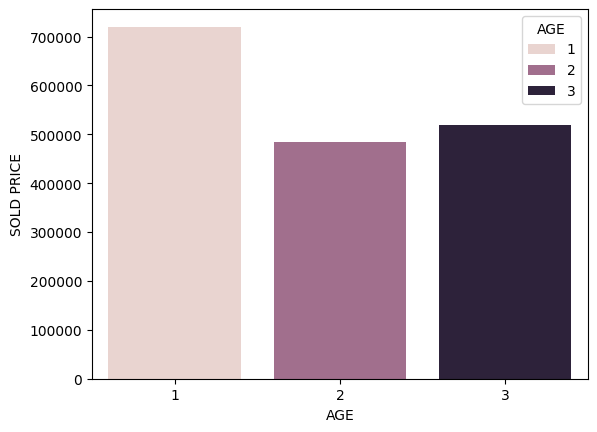

In [25]:
#Visualization using Matplotlib & Seaborne
import pandas as pd# Data Wrangling
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

soldprice_by_age=ipl_auction_df.groupby('AGE')['SOLD PRICE'].mean().reset_index()
soldprice_by_age
soldprice_by_age_role=ipl_auction_df.groupby(['AGE','PLAYING ROLE']) ['SOLD PRICE'].mean().reset_index()
#type(soldprice_by_age_role)
soldprice_comparison=soldprice_by_age_role.merge(soldprice_by_age, on='AGE', how="outer")
#type(soldprice_comparison)
sns.barplot(x='AGE', y='SOLD PRICE', hue='AGE',data=soldprice_by_age)                           
                                                 